# **BOUHOUIA Yousra REPORT Lab 5: Feature Extraction From Images and Robust Fitting**
# **(Part I)**

---

In many real-world computer vision tasks — such as object recognition, image stitching (the process of combining multiple photographic images with overlapping fields of view) — we need to identify reliable points in images that can be detected consistently, even when the scene changes slightly (e.g., different viewpoints, lighting, or noise). Edges alone are often too fragile for these tasks. Corners, on the other hand, are stronger, more distinctive, and easier to match across images.

This lab will guide you through detecting and extracting robust local features (corners), fitting geometric models robustly even in the presence of noise (using RANSAC), and taking the first steps toward feature-based image matching. You will explore different methods for feature detection, compare line fitting techniques under noise, and practice simple patch-based matching across images.


By the end of this lab, students will be able to:

1. Detect and visualize corners using the Harris Corner Detector.

2. Fit lines to noisy data using least squares, Hough Transform, and RANSAC, and compare their robustness.

3. Perform simple feature matching between images using local patch similarity.

4. Understand the impact of noise, parameter tuning, and robustness in feature extraction and model fitting.



### **Quick Recap of Previous Lab**

1. What are edges? Edges are locations in an image where there is a sudden change in intensity or color, often corresponding to object boundaries, textures, or important structures in a scene.

2. Post-processing using morphology: After detecting edges, morphological operations like dilation, erosion, opening, and closing were applied to clean up the edge maps for example, to remove noise, fill gaps, or connect broken edges.

3. Hough Transform: The Hough Transform was used to detect global shapes (lines, circles) by voting in a parameter space. It can identify structures even if the edge map is noisy or incomplete.


### **Connection to Today's Lab**


In the previous lab, we focused on detecting and enhancing edges, important low-level features that highlight object boundaries and shapes.
Today, we take the next step: instead of working only with edges, we will extract more distinctive features, such as corners, which are more stable and repeatable across different views.

We will also learn how to robustly fit models in the presence of noise and outliers, and begin building towards matching features between different images, a fundamental capability in many computer vision systems.


### Understanding the libraries used
Before starting the lab, provide a brief definition of the following libraries and their role in image processing:

- **OpenCV**: Open Source Computer Vision Library, primarily used for image and video processing tasks such as geometric transformations, filtering, and morphological operations.
  
- **NumPy**: A fundamental package for numerical computing in Python, providing support for arrays, matrices, and mathematical functions used in image processing.
  
- **Matplotlib**: A plotting library for Python that enables visualization of images, histograms, and transformations applied to images.

If not installed, you can install them using:

`pip install opencv-python numpy matplotlib`

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Manipulation 1: Detecting Object Corners Within Images

## Task 1: Harris Corner Detection
In this task, you will explore the detection of corners, highly distinctive points in an image that are robust to transformations like rotation and slight changes in viewpoint.

You will apply the Harris Corner Detection algorithm, tune its parameters, and visualize the results.
This will help you understand how feature detection differs from simple edge detection, and why corners are more reliable for tasks like matching and recognition.


![Harris Corner Detection](./Illustrations/harris.jpg)


#### **T1.1: Harris Corner Detection Using OpenCV**

- Objective: Detect and visualize corners in an image using the Harris Corner Detection method.

- Procedure:
    1. Choose an image from the Images folder.
    1. Transform your image into the grayscale.
    2. Apply the Harris Corner Detection using OpenCV’s cv2.cornerHarris() function.
    3. Tune the parameters:

        - **Threshold on corner response:** Set a threshold to select significant corners. Try different values to see how many and what quality of corners are detected.

        - **Window size (blockSize in OpenCV):** The size of the neighborhood around each pixel used for computing the corner response. Common values to test include 3x3, 5x5, and 7x7.

        - **Aperture parameter (ksize in OpenCV):** The size of the Sobel kernel used to compute image gradients. Test different values such as 3, 5, and 7 for this parameter.


        - **Sensitivity parameter (k in OpenCV):** A factor that influences the sensitivity of corner detection. This parameter is usually between 0.04 and 0.06. Test different values to see how they affect the corner detection results.

    4. Visualize detected corners over the original images for different settings (side-by-side if possible).

### **Questions**

- How do the parameters (window size, sensitivity factor k) influence the quality and number of detected corners ?
- On which images do you get the most reliable corner detection ?

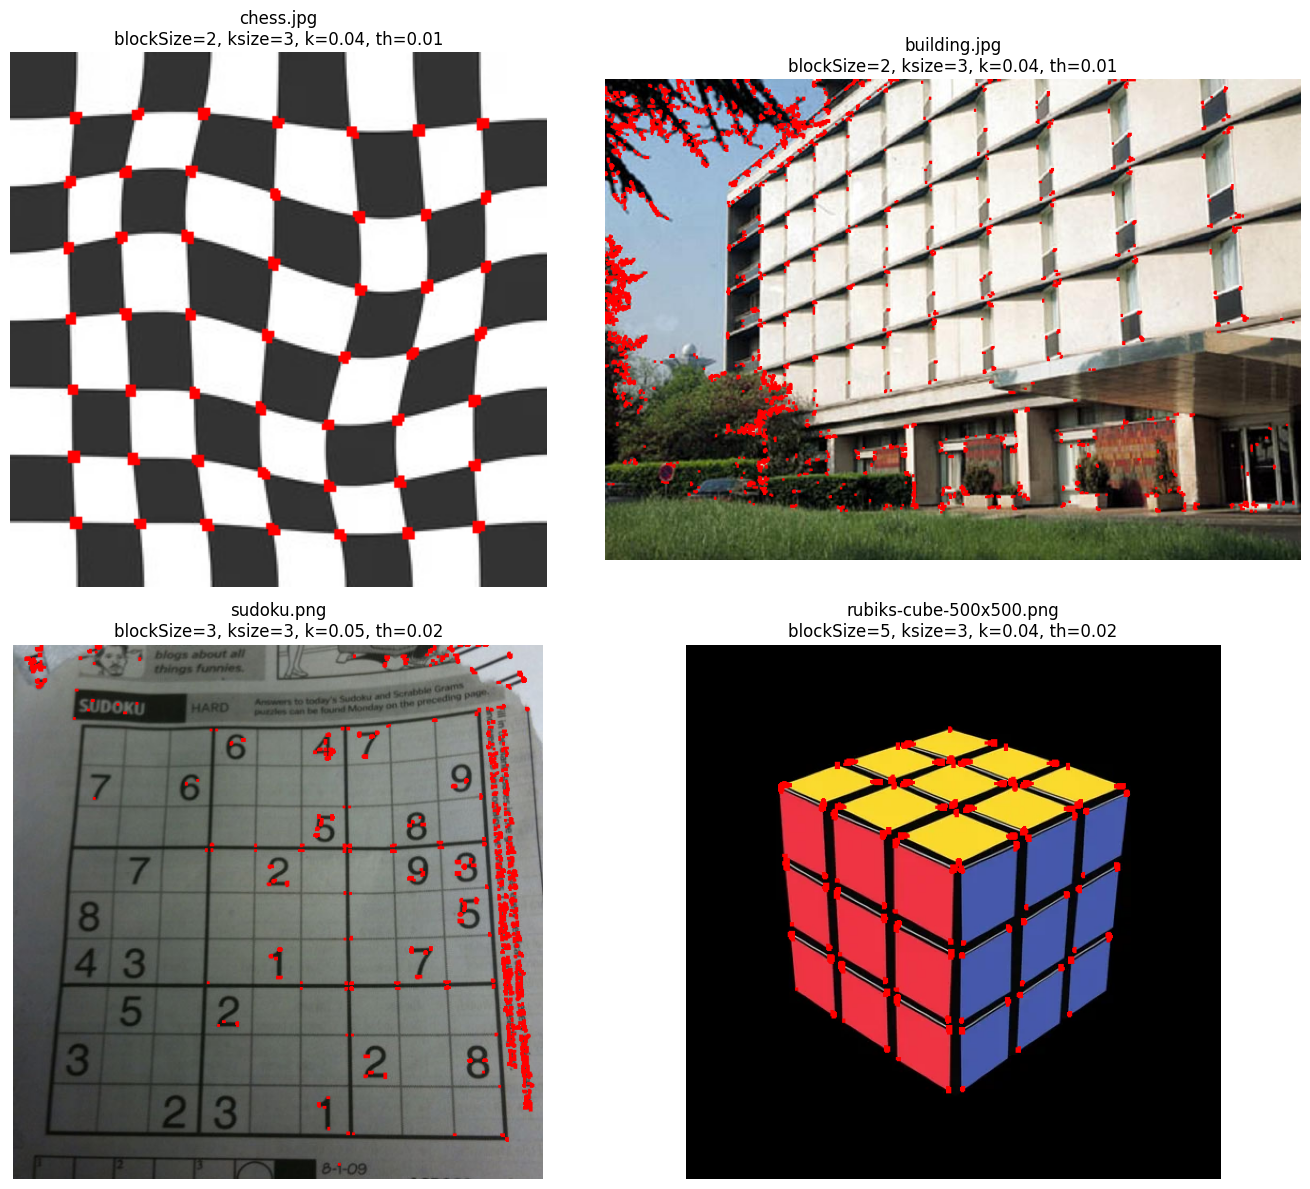

In [10]:
# Helper utilities + Harris corner detection on real images
import os
import glob
import zipfile
import tempfile
from pathlib import Path


def load_color_and_gray(image_name):
    image_path = IMAGES_DIR / image_name
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Unable to load image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return img_rgb, gray

def plot_harris_result(image_name, block_size, ksize, k, threshold_ratio):
    img_rgb, gray = load_color_and_gray(image_name)
    gray32 = np.float32(gray)
    response = cv2.cornerHarris(gray32, block_size, ksize, k)
    response = cv2.dilate(response, None)

    result = img_rgb.copy()
    threshold = threshold_ratio * response.max()
    result[response > threshold] = [255, 0, 0]

    title = (f"{image_name}\nblockSize={block_size}, ksize={ksize}, "
             f"k={k}, th={threshold_ratio}")
    return result, title

harris_experiments = [
    ("chess.jpg", 2, 3, 0.04, 0.01),
    ("building.jpg", 2, 3, 0.04, 0.01),
    ("sudoku.png", 3, 3, 0.05, 0.02),
    ("rubiks-cube-500x500.png", 5, 3, 0.04, 0.02),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, params in zip(axes.ravel(), harris_experiments):
    overlay, title = plot_harris_result(*params)
    ax.imshow(overlay)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Add your analysis and comments here**

### Analysis and comments

- The **window size (blockSize)** controls the neighborhood used to compute the corner response.
  - Small values detect more corners, including weaker and noisier ones.
  - Larger values detect fewer but more stable corners.

- The **aperture parameter (ksize)** controls the Sobel operator size.
  - Small values give finer detail.
  - Larger values smooth gradients more and may reduce noise, but can miss small corners.

- The **sensitivity factor (k)** affects how strongly corner responses are separated from edges.
  - Lower values may detect more points.
  - Higher values are usually more selective and give fewer, stronger corners.

- The **threshold** has a strong effect on the number of detected corners.
  - Lower threshold → more detected points, including false corners.
  - Higher threshold → fewer but more reliable corners.

- The most reliable corner detection is usually obtained on images with **clear geometric structures**

These images work well because they contain many sharp intensity changes and real corner intersections.
Images with smooth curves, weak texture, blur, or low contrast usually give less reliable Harris corner detection.

# Manipulation 2: Robust Line Fitting under Noise and Outliers

![Line fitting](./Illustrations/line_fitting.jpg)

In this manipulation, you will explore and compare different line fitting techniques that can be applied to datasets corrupted by noise and outliers.
Specifically, you will investigate:

- Standard Least Squares fitting (sensitive to outliers),

- Hough Transform (detecting lines in binary images),

- RANSAC (robust estimation despite heavy noise).

You will generate synthetic datasets and analyze how each method performs as the proportion of noise and outliers increases.



## **Task 1 : Polyfitting with Least Squares**

In this task, you will focus on line fitting using the Least Squares method.
You will generate synthetic data, apply polynomial fitting (degree 1 and higher), and study the sensitivity of the fitting to noise and outliers.

This task highlights the limitations of standard fitting when no explicit outlier handling is performed.

#### **T1.1: Synthetic Data Generation**

- Objective: Generate a noisy dataset for line fitting:

    - Create points lying along a line (with small random noise).
    - Add many random points as outliers (distributed in the 2D plane).

- Procedure:
    1. Create a dataset with a tunable percentage of inliers and outliers (e.g., 70% inliers, 30% outliers).
    2. Visualize the resulting dataset using a scatter plot.


### **Questions**

- How does the proportion of outliers affect the visual separability of the inlier line?
- Can you visually distinguish the true line when outliers are very dense?

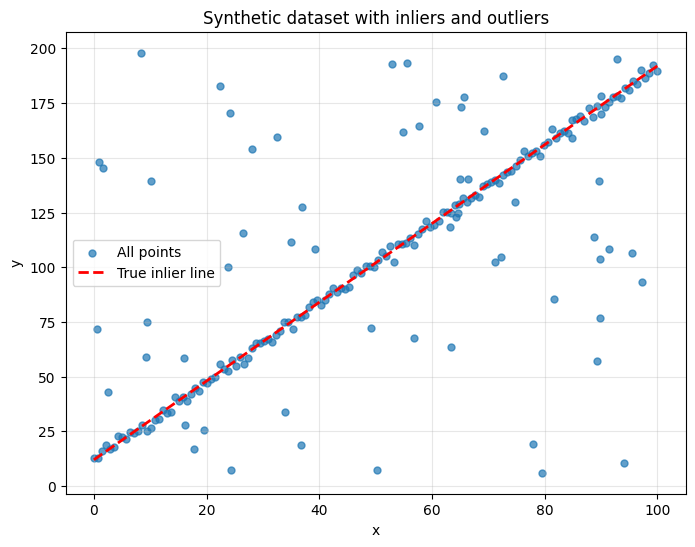

In [3]:
# Synthetic data generation for polynomial fitting
np.random.seed(42)

def generate_line_data(n_points=200, outlier_ratio=0.30, slope=1.8, intercept=12,
                       noise_std=2.0, x_range=(0, 100), y_range=(0, 200)):
    n_outliers = int(n_points * outlier_ratio)
    n_inliers = n_points - n_outliers

    x_in = np.linspace(x_range[0], x_range[1], n_inliers)
    y_true = slope * x_in + intercept
    y_in = y_true + np.random.normal(0, noise_std, n_inliers)

    x_out = np.random.uniform(x_range[0], x_range[1], n_outliers)
    y_out = np.random.uniform(y_range[0], y_range[1], n_outliers)

    x_all = np.concatenate([x_in, x_out])
    y_all = np.concatenate([y_in, y_out])

    return x_all, y_all, x_in, y_true

x_all, y_all, x_inliers, y_true_line = generate_line_data(outlier_ratio=0.30)

plt.figure(figsize=(8, 6))
plt.scatter(x_all, y_all, s=25, alpha=0.7, label="All points")
plt.plot(x_inliers, y_true_line, "r--", linewidth=2, label="True inlier line")
plt.title("Synthetic dataset with inliers and outliers")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis and comments

- The generated dataset shows a clear linear trend formed by the inlier points, while the outliers are scattered randomly across the plane.
- In this example, the true inlier trend is still easy to distinguish visually because most inlier points remain close to the diagonal pattern.
- The outlier proportion affects the visual separability of the inlier structure:
  - with fewer outliers, the linear trend is very clear,
  - with more outliers, the trend becomes harder to distinguish.
- If outliers become very dense, it may become difficult to identify the true inlier trend by visual inspection alone.

#### **T1.2: Line Fitting without Outlier Rejection**


- Objective: Fit lines to the noisy dataset without explicitly handling outliers.


- Procedure:
    1. Fit a linear model (degree 1 polynomial) using np.polyfit().
    2. Fit a nonlinear model (degree 2 or 3 polynomial) and observe the behavior.
    3. Plot the fitted lines/curves over the noisy dataset.

### **Questions**

- How does the fitted model behave as the percentage of outliers increases?
- Is the linear model or the nonlinear model more robust to outliers in this case?


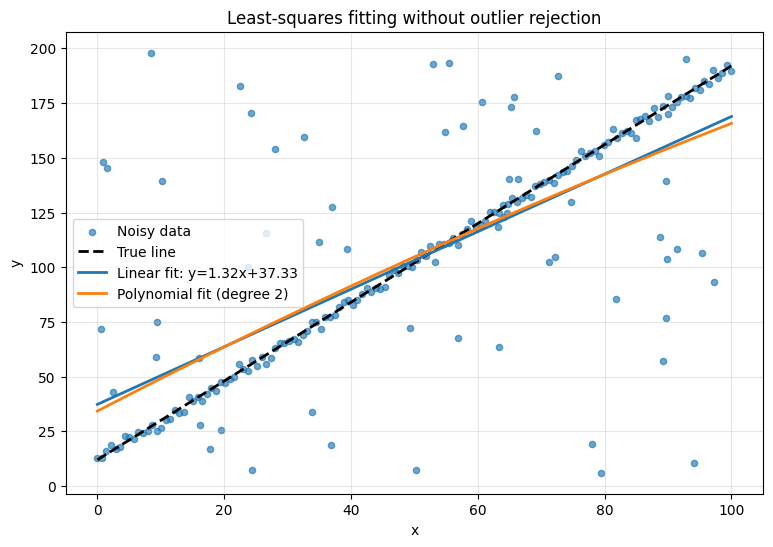

Degree-1 coefficients: [ 1.31541745 37.32992961]
Degree-2 coefficients: [-1.88545262e-03  1.50306647e+00  3.42761792e+01]


In [4]:
# Line fitting without explicit outlier rejection
coeff_deg1 = np.polyfit(x_all, y_all, deg=1)
coeff_deg2 = np.polyfit(x_all, y_all, deg=2)

poly_deg1 = np.poly1d(coeff_deg1)
poly_deg2 = np.poly1d(coeff_deg2)

x_plot = np.linspace(np.min(x_all), np.max(x_all), 400)

plt.figure(figsize=(9, 6))
plt.scatter(x_all, y_all, s=20, alpha=0.65, label="Noisy data")
plt.plot(x_inliers, y_true_line, "k--", linewidth=2, label="True line")
plt.plot(x_plot, poly_deg1(x_plot), linewidth=2, label=f"Linear fit: y={coeff_deg1[0]:.2f}x+{coeff_deg1[1]:.2f}")
plt.plot(x_plot, poly_deg2(x_plot), linewidth=2, label="Polynomial fit (degree 2)")
plt.title("Least-squares fitting without outlier rejection")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Degree-1 coefficients:", coeff_deg1)
print("Degree-2 coefficients:", coeff_deg2)

**Add your analysis and comments here**

### Analysis and comments

- The linear fit (degree 1) and polynomial fit (degree 2) do not perfectly match the true inlier line because the fitting process uses all points, including the outliers.
- Least squares minimizes the sum of squared residuals, so points that are far from the true trend have a strong influence on the result.
- This makes the method sensitive to outliers and can shift the fitted model away from the true underlying line.
- In the figure, the fitted straight line has a lower slope and a higher intercept than the true line, showing the effect of the outliers.
- The polynomial fit is also affected and bends slightly to adapt to the noisy dataset.
- This demonstrates one of the main limitations of standard least-squares fitting when no outlier rejection is used.

#### **T1.3: Evaluation: Effect of Outliers**

- Objective: Quantitatively evaluate the robustness of fitting methods.

- Procedure: 

    1. Vary the percentage of outliers in the dataset (e.g., 0%, 20%, 30%... up to 90%) and perform the fitting for each case.

    2. For each fitting (linear and nonlinear):
        - Fit linear and nonlinear models.
        - compute the Mean Squared Error (MSE) between the predicted and true inlier points.

    3. Plot a graph showing MSE vs. Outlier Percentage for:
        - Linear fitting (degree 1)
        - Nonlinear fitting (degree 2 or more)

### **Questions:**

- Which model shows lower MSE at high outlier rates?
- What does the MSE trend tell you about each model’s sensitivity to noise?





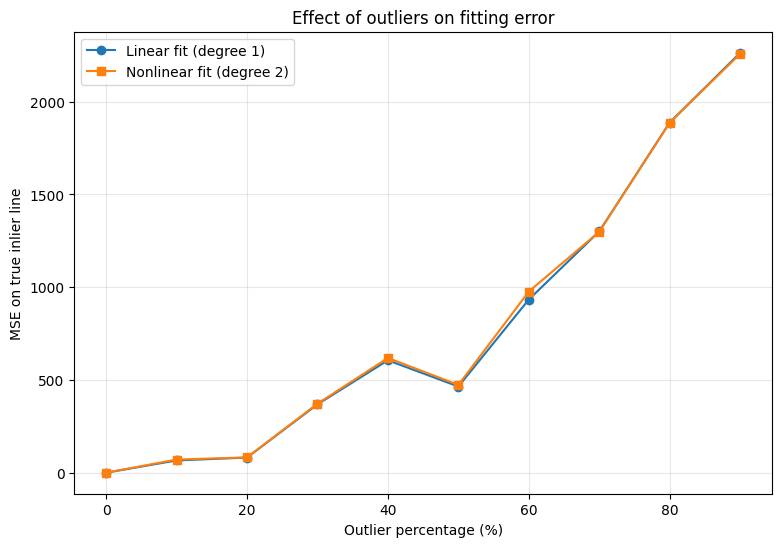

In [5]:
# Evaluation: MSE versus outlier percentage
outlier_percentages = np.arange(0, 100, 10)
mse_deg1 = []
mse_deg2 = []

for pct in outlier_percentages:
    x_all_tmp, y_all_tmp, x_in_tmp, y_true_tmp = generate_line_data(outlier_ratio=pct / 100.0)

    fit1 = np.poly1d(np.polyfit(x_all_tmp, y_all_tmp, deg=1))
    fit2 = np.poly1d(np.polyfit(x_all_tmp, y_all_tmp, deg=2))

    pred1 = fit1(x_in_tmp)
    pred2 = fit2(x_in_tmp)

    mse_deg1.append(np.mean((pred1 - y_true_tmp) ** 2))
    mse_deg2.append(np.mean((pred2 - y_true_tmp) ** 2))

plt.figure(figsize=(9, 6))
plt.plot(outlier_percentages, mse_deg1, marker="o", label="Linear fit (degree 1)")
plt.plot(outlier_percentages, mse_deg2, marker="s", label="Nonlinear fit (degree 2)")
plt.title("Effect of outliers on fitting error")
plt.xlabel("Outlier percentage (%)")
plt.ylabel("MSE on true inlier line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis and comments

- The MSE increases as the outlier percentage increases, which shows that both models become less accurate when more outliers are added. 
- The two curves are very close, so the linear and degree 2 models behave similarly in this experiment. 
- At high outlier rates, both errors become very large, which means both methods are sensitive to outliers and are not robust in noisy data.

## **Task 2: Line Detection Using the Hough Transform and RANSAC**

#### **Task 2.1: Applying Hough Transform**

- **Objective:**  
  Detect lines using the Hough Transform on noisy datasets with varying levels of outliers.

- **Procedure:**

    1. Generate a synthetic dataset composed of points that approximately follow a line of the form *y = ax + b*, while progressively adding more outliers (e.g., 0%, 20%, 40%, 60%, 80%).

    2. Convert the points into a binary image (white points on a black background).
       - You can refer to an example in the `Images` folder (e.g., `binary_image.png`).

    3. Apply OpenCV’s `cv2.HoughLines()` function to detect lines in the binary image.

    4. Plot the detected lines over the original set of points for visual analysis.




![Line fitting](./Illustrations/hough_vs_ransac_1a.png)
![Line fitting](./Illustrations/hough_vs_ransac_1b.png)

---


![Line fitting](./Illustrations/hough_vs_ransac_2a.png)
![Line fitting](./Illustrations/hough_vs_ransac_2b.png)



### **Questions**

- How sensitive is the Hough Transform to its parameter settings (e.g., threshold)?

- What types of errors are typical with Hough Transform under heavy noise?

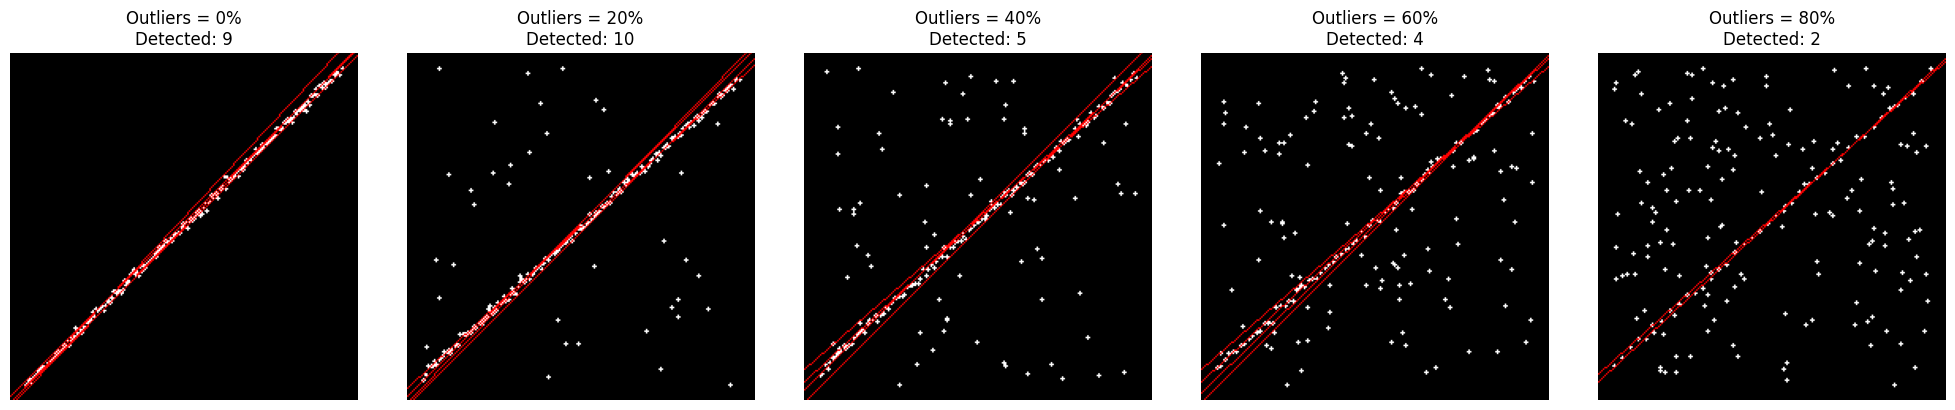

In [6]:
# Hough Transform on synthetic noisy point sets
def points_to_binary_image(x, y, img_size=(220, 220)):
    h, w = img_size
    canvas = np.zeros((h, w), dtype=np.uint8)

    x_norm = np.interp(x, (np.min(x), np.max(x)), (10, w - 10)).astype(int)
    y_norm = np.interp(y, (np.min(y), np.max(y)), (h - 10, 10)).astype(int)

    for xi, yi in zip(x_norm, y_norm):
        cv2.circle(canvas, (xi, yi), 1, 255, -1)
    return canvas, x_norm, y_norm

def draw_hough_lines(binary_img, original_points_img, threshold=60):
    lines = cv2.HoughLines(binary_img, 1, np.pi / 180, threshold)
    overlay = cv2.cvtColor(original_points_img.copy(), cv2.COLOR_GRAY2RGB)

    if lines is not None:
        for line in lines[:4]:
            rho, theta = line[0]
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * a))
            pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * a))
            cv2.line(overlay, pt1, pt2, (255, 0, 0), 1)
    return overlay, lines

outlier_levels = [0.0, 0.2, 0.4, 0.6, 0.8]

fig, axes = plt.subplots(1, len(outlier_levels), figsize=(20, 4))
for ax, ratio in zip(axes, outlier_levels):
    x_tmp, y_tmp, _, _ = generate_line_data(outlier_ratio=ratio, noise_std=1.5)
    binary_img, _, _ = points_to_binary_image(x_tmp, y_tmp)
    overlay, lines = draw_hough_lines(binary_img, binary_img, threshold=45)

    ax.imshow(overlay)
    ax.set_title(f"Outliers = {int(ratio*100)}%\nDetected: {0 if lines is None else len(lines)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

**Add your analysis and comments here**

### Analysis and comments

- The Hough Transform successfully detects the dominant diagonal line for all tested outlier levels. When the outlier percentage is low, the diagonal structure is very clear, so the algorithm detects several similar lines close to the true line. This happens because many points support the same line direction, which creates strong votes in the Hough space.

- As the outlier percentage increases from 20% to 80%, the image becomes noisier and the number of detected lines decreases. Even with more random points in the background, the main diagonal line is still detected. This shows that the Hough Transform is relatively robust to outliers when there is still a strong global alignment of inlier points.

- At low outlier levels, the detections are stronger and more numerous because many inlier points contribute to the same line.
- At high outlier levels, fewer inlier points remain on the true structure, so the voting becomes weaker and fewer valid lines are detected. However, the main trend is still preserved because the inlier points continue to follow the same diagonal direction.

- Compared with RANSAC in the previous examples, the Hough Transform appears more stable for this binary-image line detection task. The detected Hough lines remain closely aligned with the real diagonal structure, while RANSAC can be more affected by random sampling and noise.

Overall, these results show that the Hough Transform is effective for detecting dominant straight lines in noisy binary data. Its performance decreases as the outlier level increases, but it still identifies the main line even in difficult cases.

#### **T2.2: Applying RANSAC**

- Objective: Detect the correct line using RANSAC in the presence of heavy noise.

- Procedure:

    1. Use sklearn.linear_model.RANSACRegressor.

    2. Fit the model to the noisy data.

    3. Compare visually with:
        - Least Squares fitting.
        - Hough Transform detection.


### **Questions**

- Why is RANSAC more robust to heavy noise compared to Least Squares and Hough Transform?

- How does RANSAC handle outliers differently than the other methods?

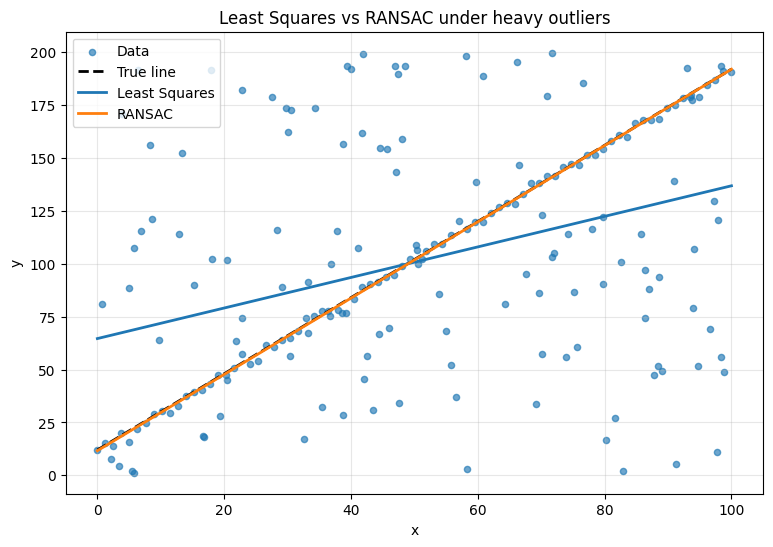

Least Squares slope/intercept: 0.7221584214283067 64.64326760134577
RANSAC slope/intercept: 1.8031614844758517 11.6371472786945
Estimated inliers by RANSAC: 88 / 200


In [7]:
# RANSAC versus Least Squares on a heavily corrupted dataset
from sklearn.linear_model import LinearRegression, RANSACRegressor

x_r, y_r, x_in_r, y_true_r = generate_line_data(outlier_ratio=0.60, noise_std=2.0)
X_r = x_r.reshape(-1, 1)

least_squares = LinearRegression()
least_squares.fit(X_r, y_r)

ransac = RANSACRegressor(estimator=LinearRegression(), random_state=42,
                         residual_threshold=6.0, max_trials=200)
ransac.fit(X_r, y_r)

x_plot = np.linspace(np.min(x_r), np.max(x_r), 400).reshape(-1, 1)
y_ls = least_squares.predict(x_plot)
y_ransac = ransac.predict(x_plot)

plt.figure(figsize=(9, 6))
plt.scatter(x_r, y_r, s=20, alpha=0.65, label="Data")
plt.plot(x_in_r, y_true_r, "k--", linewidth=2, label="True line")
plt.plot(x_plot, y_ls, linewidth=2, label="Least Squares")
plt.plot(x_plot, y_ransac, linewidth=2, label="RANSAC")
plt.title("Least Squares vs RANSAC under heavy outliers")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Least Squares slope/intercept:", least_squares.coef_[0], least_squares.intercept_)
print("RANSAC slope/intercept:", ransac.estimator_.coef_[0], ransac.estimator_.intercept_)
print("Estimated inliers by RANSAC:", int(ransac.inlier_mask_.sum()), "/", len(ransac.inlier_mask_))

**Add your analysis and comments here**

### Analysis and comments

In this experiment, RANSAC performs much better than Least Squares under heavy outliers. The Least Squares line is clearly pulled away from the true line because it uses all data points, including many outliers. As a result, its slope and intercept are far from the true values.

In contrast, the RANSAC line closely matches the true line. This is because RANSAC identifies the dominant inlier points and fits the model mainly to them, while ignoring most outliers. The estimated RANSAC slope and intercept are very close to the true line parameters, which shows that it is more robust in noisy conditions.

Overall, this result shows that RANSAC handles outliers more effectively than Least Squares. It is therefore a better method when the dataset contains heavy noise or many incorrect points.

#### **T2.3: Comparison between Hough Transform and RANSAC**

- **Objective:**  
  Evaluate the robustness of Hough Transform and RANSAC under increasing levels of outliers in the data.

- **Procedure:**

    1. For each dataset:
        - Create a binary image of the points (white points on a black background).
        - Apply the **Hough Transform** to detect lines.
        - Apply **RANSAC** to fit a line to the data.
        
    2. Plot and visually compare the results:
        - Lines detected by the Hough Transform.
        - The fitted line obtained with RANSAC.

    3. Record observations regarding how each method handles increasing amounts of noise and outliers.

    4. Extend the experiment:
        - Redo **Task T2.1** and **Task T2.2** using a binary image containing **two true lines** instead of one.
        - Repeat the evaluation under various levels of added noise and outliers.

### **Questions**

- How does the detection quality of the **Hough Transform** change as the number of outliers increases? In what situations might Hough still successfully detect meaningful structures despite noise?

- How does the performance of **RANSAC** evolve as the proportion of outliers increases? Does RANSAC always correctly estimate the main structure?

- What are the strengths and limitations of the **Hough Transform** when multiple lines or noisy line segments are present?

- What are the strengths and limitations of **RANSAC** when attempting to detect a single dominant line in heavily corrupted data?

- What kinds of post-processing might be necessary when using Hough Transform or RANSAC in real-world applications?


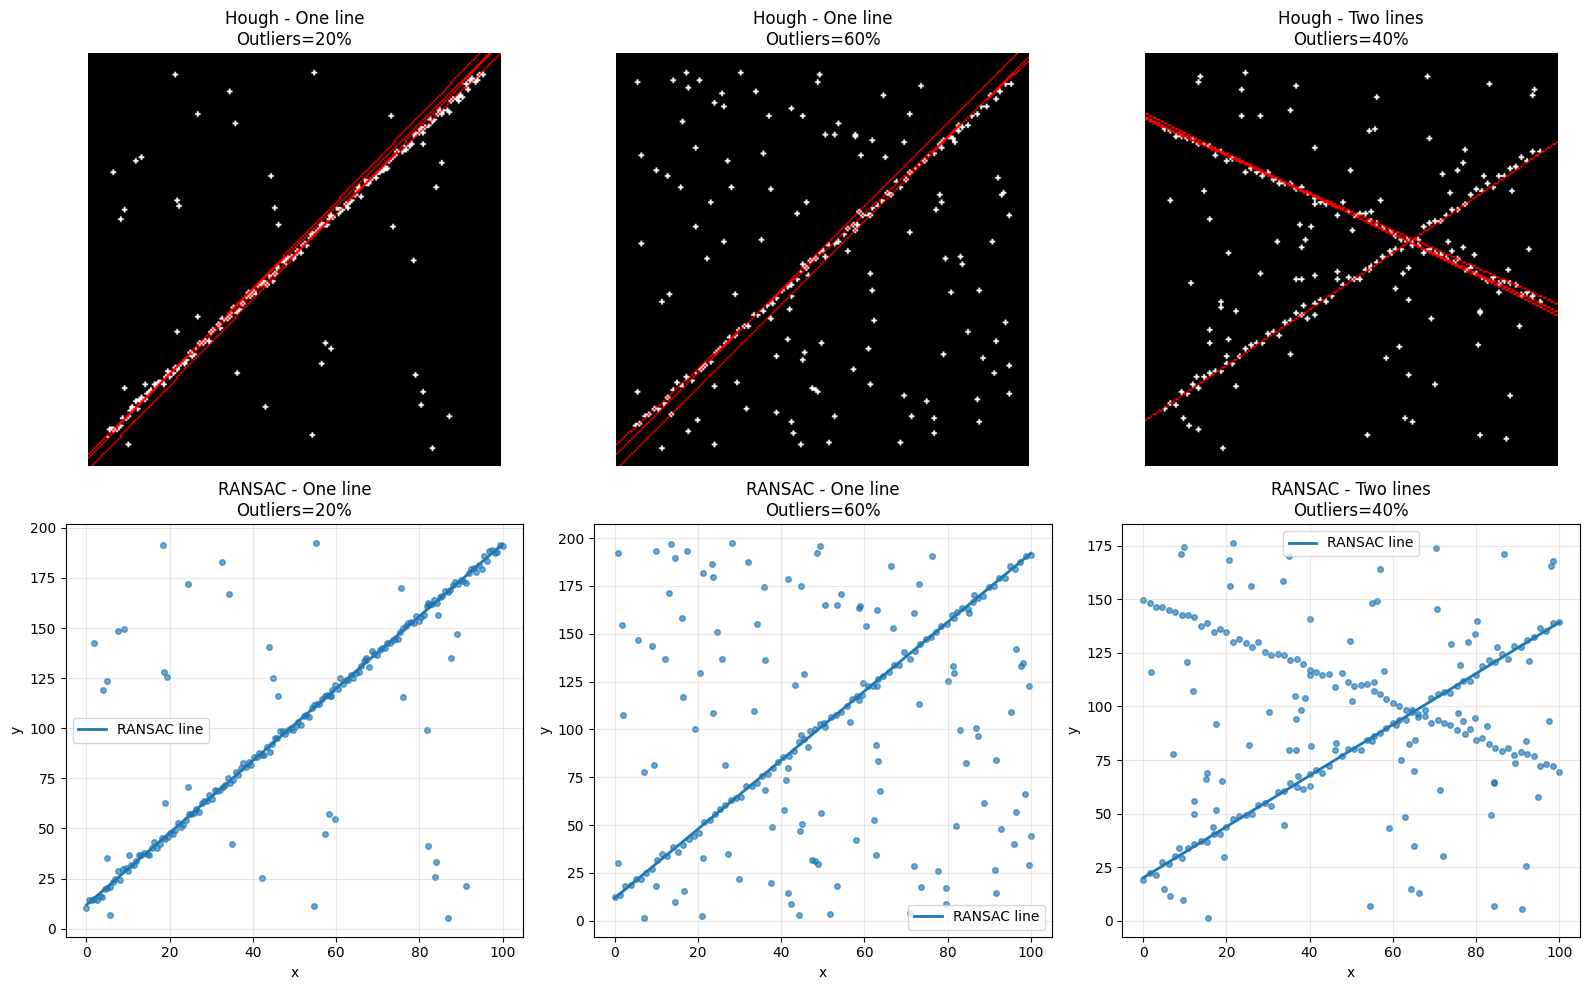

In [8]:
# Comparison between Hough Transform and RANSAC with one line and two lines
def generate_two_line_data(n_points=220, outlier_ratio=0.35, noise_std=1.5):
    n_outliers = int(n_points * outlier_ratio)
    n_signal = n_points - n_outliers
    n1 = n_signal // 2
    n2 = n_signal - n1

    x1 = np.linspace(0, 100, n1)
    y1 = 1.2 * x1 + 20 + np.random.normal(0, noise_std, n1)

    x2 = np.linspace(0, 100, n2)
    y2 = -0.8 * x2 + 150 + np.random.normal(0, noise_std, n2)

    x_out = np.random.uniform(0, 100, n_outliers)
    y_out = np.random.uniform(0, 180, n_outliers)

    x = np.concatenate([x1, x2, x_out])
    y = np.concatenate([y1, y2, y_out])
    return x, y

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
configs = [("One line", 0.2, False), ("One line", 0.6, False), ("Two lines", 0.4, True)]

for col, (label, ratio, use_two_lines) in enumerate(configs):
    if use_two_lines:
        x_cmp, y_cmp = generate_two_line_data(outlier_ratio=ratio)
    else:
        x_cmp, y_cmp, _, _ = generate_line_data(outlier_ratio=ratio, noise_std=1.5)

    binary_img, _, _ = points_to_binary_image(x_cmp, y_cmp)
    hough_overlay, _ = draw_hough_lines(binary_img, binary_img, threshold=40)

    X_cmp = x_cmp.reshape(-1, 1)
    ransac_cmp = RANSACRegressor(estimator=LinearRegression(), random_state=42,
                                 residual_threshold=6.0, max_trials=200)
    ransac_cmp.fit(X_cmp, y_cmp)

    x_vis = np.linspace(np.min(x_cmp), np.max(x_cmp), 300)
    y_ransac_cmp = ransac_cmp.predict(x_vis.reshape(-1, 1))

    axes[0, col].imshow(hough_overlay)
    axes[0, col].set_title(f"Hough - {label}\nOutliers={int(ratio*100)}%")
    axes[0, col].axis("off")

    axes[1, col].scatter(x_cmp, y_cmp, s=16, alpha=0.65)
    axes[1, col].plot(x_vis, y_ransac_cmp, linewidth=2, label="RANSAC line")
    axes[1, col].set_title(f"RANSAC - {label}\nOutliers={int(ratio*100)}%")
    axes[1, col].set_xlabel("x")
    axes[1, col].set_ylabel("y")
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].legend()

plt.tight_layout()
plt.show()

**Add your analysis and comments here**

### Analysis and comments

This comparison shows that both Hough Transform and RANSAC can detect the main line when the dataset contains one dominant structure, but their behavior changes as the number of outliers increases. In the one-line case with 20% outliers, both methods perform well. The Hough Transform detects several lines close to the true diagonal because many points vote for the same direction, while RANSAC estimates a single line that fits the inlier trend very closely.

When the outlier percentage increases to 60%, both methods are still able to recover the main diagonal structure, but the effect of noise becomes more visible. For Hough Transform, the number of strong detections decreases because fewer inlier points contribute consistent votes. For RANSAC, the fitted line still matches the dominant trend well, showing that it remains robust even under heavier corruption.

In the two-line case, the difference between the methods becomes clearer. The Hough Transform is able to detect both dominant line structures because it searches for multiple peaks in parameter space. This makes it especially useful when the image contains several meaningful lines. RANSAC, however, fits only one dominant line at a time, so it captures one of the two structures but does not represent both simultaneously unless it is applied repeatedly with additional post-processing.

The results therefore highlight the main strengths of each method. Hough Transform is better when the goal is to detect multiple global line structures in binary image data. RANSAC is better when the goal is to robustly estimate a single dominant line in the presence of many outliers.

| Method | Strengths | Limitations |
|--------|-----------|-------------|
| **Hough Transform** | Detects multiple lines, works well on binary images, robust when line votes are strong | Can return many similar detections, performance weakens as outliers increase |
| **RANSAC** | Robust for fitting one dominant line, handles outliers well, gives a clean single estimate | Usually detects only one line at a time, may miss additional structures |

Overall, these experiments show that Hough Transform is more suitable for detecting multiple line structures, while RANSAC is more suitable for robust single-line fitting. Both methods are useful, but their effectiveness depends on whether the task requires finding one dominant model or several meaningful lines.

## **Task 3: Parameter Tuning and Analysis of Line Detection Methods**


#### **T3.1: Experimental Analysis and Parameter Tuning**


### Objective:
In this task, you will redo **Task 2** and **Task 3** using different real images and different parameter settings. This will help you explore the impact of different parameters on the results and understand the effect of noise and outliers on line (or curve) detection in real-world scenarios.

### Procedure:

1. **Parameter Tuning:**
   - Experiment with different parameter settings for the **Hough Transform** and binary image creation.
   - Explore how changes in the **rho**, **theta**, and **threshold** parameters affect the detection performance, particularly under varying noise levels and the presence of outliers.
   - Investigate how **RANSAC** parameters (such as the number of iterations and the threshold for inliers) impact the robustness of line or curve fitting.
   - Record how each parameter influences the results and identify the optimal configuration for line detection in realistic, noisy images.

2. **Analysis:**
   - Compare the performance of the **Hough Transform** and **RANSAC** on images with varying amounts of noise and outliers.
   - Discuss how the parameters you tuned impacted the detection of lines (or curves) and how they relate to the image characteristics (e.g., noise level, outlier distribution, etc.).
   - Reflect on how well **RANSAC** performed in fitting curves as compared to lines.
   - Evaluate how both methods (Hough Transform and RANSAC) performed on real-world images compared to synthetic datasets, and assess the practicality of parameter tuning in real applications.
   - Consider the advantages and limitations of each method in different scenarios (e.g., single line, multiple lines, curves), and how parameter tuning affects their robustness and efficiency.



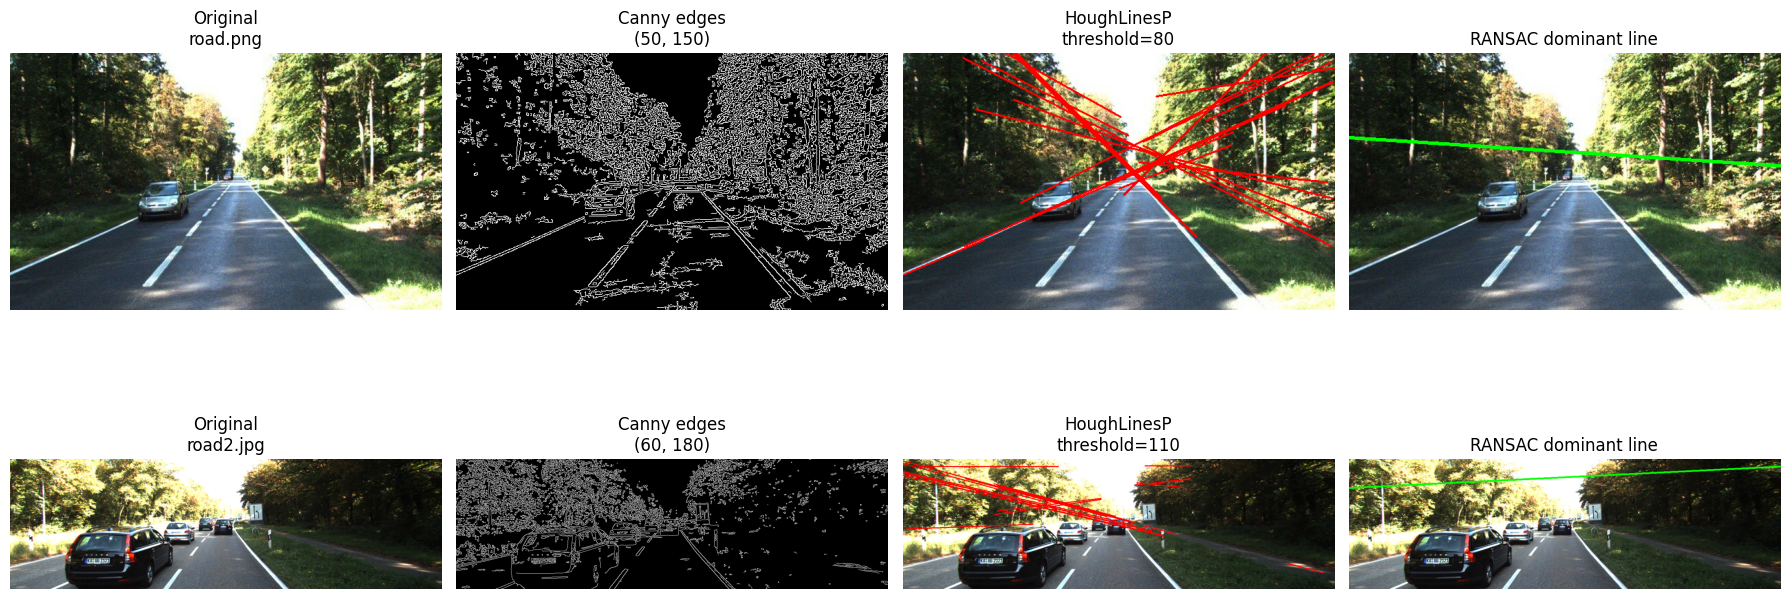

In [9]:
# Parameter tuning and analysis on real images
def detect_lines_in_real_image(image_name, canny1=50, canny2=150,
                               hough_threshold=120, min_line_length=60, max_line_gap=10):
    image_path = IMAGES_DIR / image_name
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Unable to load image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, canny1, canny2)

    hough_img = img_rgb.copy()
    lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=hough_threshold,
                              minLineLength=min_line_length, maxLineGap=max_line_gap)
    if lines_p is not None:
        for line in lines_p[:20]:
            x1, y1, x2, y2 = line[0]
            cv2.line(hough_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    points = np.column_stack(np.where(edges > 0))  # (y, x)
    ransac_img = img_rgb.copy()
    if len(points) > 10:
        X = points[:, 1].reshape(-1, 1)
        y = points[:, 0]
        ransac_model = RANSACRegressor(estimator=LinearRegression(), random_state=42,
                                       residual_threshold=2.5, max_trials=300)
        ransac_model.fit(X, y)
        x_vis = np.array([X.min(), X.max()]).reshape(-1, 1)
        y_vis = ransac_model.predict(x_vis).astype(int)
        cv2.line(ransac_img, (int(x_vis[0, 0]), int(y_vis[0])),
                 (int(x_vis[1, 0]), int(y_vis[1])), (0, 255, 0), 3)

    return img_rgb, edges, hough_img, ransac_img

real_experiments = [
    ("road.png", 50, 150, 80, 70, 15),
    ("road2.jpg", 60, 180, 110, 80, 20),
]

fig, axes = plt.subplots(len(real_experiments), 4, figsize=(18, 8))
if len(real_experiments) == 1:
    axes = np.array([axes])

for row, (image_name, c1, c2, ht, min_len, max_gap) in enumerate(real_experiments):
    original, edges, hough_img, ransac_img = detect_lines_in_real_image(
        image_name, canny1=c1, canny2=c2, hough_threshold=ht,
        min_line_length=min_len, max_line_gap=max_gap
    )

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original\n{image_name}")
    axes[row, 1].imshow(edges, cmap="gray")
    axes[row, 1].set_title(f"Canny edges\n({c1}, {c2})")
    axes[row, 2].imshow(hough_img)
    axes[row, 2].set_title(f"HoughLinesP\nthreshold={ht}")
    axes[row, 3].imshow(ransac_img)
    axes[row, 3].set_title("RANSAC dominant line")

    for col in range(4):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

**Add your analysis and comments here**

### Analysis and comments

In these real-image experiments, parameter tuning has a strong effect on the quality of line detection. The Canny thresholds control how many edges are extracted from the image. When many edges are detected, the Hough Transform produces several line candidates, including irrelevant lines from trees, cars, and road boundaries. This shows that Hough is sensitive to the edge map quality and can return many false detections in cluttered scenes.

For the road images, Hough Transform is still able to detect meaningful line segments, especially along the lane markings and road borders, but the results are noisy because the images contain many textures and non-road edges. Changing the Hough threshold affects the number of detected lines: lower thresholds detect more lines, while higher thresholds are more selective but may miss some useful structures.

RANSAC, on the other hand, produces only one dominant line. In these examples, the detected RANSAC line does not align well with the actual road lane direction. Instead, it captures a broader dominant trend influenced by the overall edge distribution. This shows that RANSAC is less suitable here when the image contains multiple meaningful lines rather than one single dominant structure.

Overall, the experiment shows that Hough Transform is more appropriate for real road images because it can detect multiple line segments, but it requires careful tuning to reduce false positives. RANSAC is more robust for fitting one dominant line in noisy point data, but in complex real images it may oversimplify the scene and miss important lane structures.

#### **T3.2: Summary Table: Method Comparison**

Fill this table based on your experimental results and discussion:
Mark **Yes**, **No** or **Moderate** according to the behavior you observe for each method.


| **Criterion**           | **Least Squares** | **Hough Transform** | **RANSAC** |
|:------------------------|:------------------|:--------------------|:-----------|
| Robust to Outliers      | No                | Moderate            | Yes        |
| Easy to Implement       | Yes               | Moderate            | Moderate   |
| Need to Tune Parameters | No                | Yes                 | Yes        |
| Works with Sparse Points| Moderate          | No                  | Yes        |




---

## **Reflection Questions (Final Discussion)**

1. In which situations is Hough Transform preferable despite its weaknesses?

2. Why does RANSAC outperform other methods when a large number of outliers is present?

3. How would you modify Hough Transform or RANSAC to make them even more robust?




**1. In which situations is Hough Transform preferable despite its weaknesses?**  
Hough Transform is preferable when the goal is to detect multiple line structures in an image, especially in binary or edge images. It is useful when lines are visually strong and globally consistent, such as lane markings, road boundaries, or clear geometric shapes. Even though it can produce false detections in noisy scenes, it is still valuable when we want to find several meaningful lines at the same time.

**2. Why does RANSAC outperform other methods when a large number of outliers is present?**  
RANSAC performs better because it does not try to fit all points at once. Instead, it repeatedly chooses small random samples, estimates a model, and keeps the one supported by the largest number of inliers. This allows it to ignore many outliers and focus on the true structure. Least Squares is more affected because all points influence the fit, while Hough Transform may weaken when noise produces many irrelevant votes.

**3. How would you modify Hough Transform or RANSAC to make them even more robust?**  
To improve Hough Transform, I would first apply better preprocessing, such as smoothing, edge filtering, and restricting the region of interest, so that fewer irrelevant edges are included. I would also tune the voting threshold and minimum line length carefully. To improve RANSAC, I would increase the number of iterations, choose a suitable inlier threshold, and apply it repeatedly if multiple lines need to be detected. Combining preprocessing with parameter tuning would make both methods more robust in difficult real-world images.